# Financial Risk Monte Carlo Simulation

## 1. Problem Definition
We are building a comprehensive risk model for a multi-asset financial portfolio. We aim to assess the tail risk of holding stocks (e.g., AAPL, MSFT, and GOOGL) over a specific time horizon, typically quantifying this risk as Value at Risk (VaR) and Expected Shortfall (ES).


## 2. Model Development
We will use **Multi-Dimensional Geometric Brownian Motion (GBM)** to simulate future price paths. A single asset following GBM satisfies the SDE:

$dS_t = \mu S_t dt + \sigma S_t dW_t$

When discretely modeled with multiple correlated assets over $\Delta t$, the price evolution becomes:

$S_{i, t} = S_{i, t-1} \cdot \exp\left(\left( \mu_i - \frac{\sigma_i^2}{2} \right) \Delta t + \sigma_i \sqrt{\Delta t} Z_{i,t}\right)$ 

Where $Z_{i,t}$ is a vector of correlated standard normal random variables derived using the Cholesky decomposition of the correlation matrix.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


### 2.1 Fetching Historical Data
Let's pull 5 years of historical adjusted close prices for our portfolio using `yfinance`.


In [7]:
tickers = ['AAPL', 'MSFT', 'GOOGL']
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=5)

# Fetch data
data = yf.download(tickers, start=start_date, end=end_date)['Close']
data.dropna(inplace=True)

# Calculate daily logarithmic returns
log_returns = np.log(data / data.shift(1)).dropna()

display(data.head())
display(log_returns.head())


[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOGL,MSFT
Date,,,
2021-05-03,129.093353,116.193665,241.674698
2021-05-04,124.525345,114.396027,237.769302
2021-05-05,124.768829,114.789764,236.502670
2021-05-06,126.366196,115.909500,239.630814
2021-05-07,127.039391,116.632538,242.250412


Ticker,AAPL,GOOGL,MSFT
Date,,,
2021-05-04,-0.036027,-0.015592,-0.016292
2021-05-05,0.001953,0.003436,-0.005341
2021-05-06,0.012721,0.009707,0.013140
2021-05-07,0.005313,0.006219,0.010872
2021-05-10,-0.026143,-0.025921,-0.021136


### 2.2 Parameter Estimation
We estimate historical mean returns, volatility, and the correlation matrix.


In [8]:
# Portfolio weights (Equally weighted)
weights = np.array([1/len(tickers)] * len(tickers))

# Estimate mean daily return and daily volatility
mean_returns = log_returns.mean().values
volatilities = log_returns.std().values

# Calculate Covariance and Correlation Matrices
cov_matrix = log_returns.cov()
corr_matrix = log_returns.corr()

print("Mean Daily Returns:\n", mean_returns)
print("\nDaily Volatilities:\n", volatilities)
print("\nCorrelation Matrix:\n", corr_matrix)


Mean Daily Returns:
 [0.00061733 0.000956   0.00042975]

Daily Volatilities:
 [0.0172762  0.01962229 0.01663741]

Correlation Matrix:
 Ticker      AAPL     GOOGL      MSFT
Ticker                              
AAPL    1.000000  0.564623  0.588590
GOOGL   0.564623  1.000000  0.593178
MSFT    0.588590  0.593178  1.000000


## 3. Simulation Implementation
We create a Monte Carlo simulation engine. We'll use the Cholesky decomposition of the covariance matrix to simulate correlated random variables.


In [16]:
# Simulation Parameters
num_simulations = 10000  # Number of Monte Carlo paths
time_horizon = 252        # 21 trading days (approx 1 month)
initial_portfolio_value = 100000  # Initial investment in USD
np.random.seed(42)

# Determine initial asset values based on weights
initial_investment_per_asset = initial_portfolio_value * weights
initial_prices = data.iloc[-1].values
shares_held = initial_investment_per_asset / initial_prices

# We need the lower triangular matrix L from Cholesky decomposition of the covariance matrix
# Such that L @ L.T = Covariance Matrix
L = np.linalg.cholesky(cov_matrix)

# Initialize an array to store simulated portfolio end values
portfolio_end_values = np.zeros(num_simulations)
portfolio_paths = np.zeros((time_horizon, num_simulations)) # To track total portfolio value over time

# Run the Monte Carlo Simulation
for i in range(num_simulations):
    # Generating uncorrelated random variables
    Z = np.random.standard_normal((time_horizon, len(tickers)))
    
    # Correlating them using Cholesky lower triangular matrix
    # Note: Z is (time_horizon, assets), L is (assets, assets)
    # We want correlated random shocks: dW = Z @ L.T
    dW = Z.dot(L.T)
    
    # Simulate price paths using Multi-Dimensional GBM
    # Pre-allocate simulated prices matrix
    simulated_prices = np.zeros((time_horizon + 1, len(tickers)))
    simulated_prices[0] = initial_prices
    
    for t in range(1, time_horizon + 1):
        # We use the discretized GBM solution
        drift = mean_returns - (0.5 * volatilities**2)
        shock = dW[t-1]
        simulated_prices[t] = simulated_prices[t-1] * np.exp(drift + shock)
        
    # Calculate portfolio value at the end of the horizon
    portfolio_value_path = np.dot(simulated_prices, shares_held)
    portfolio_paths[:, i] = portfolio_value_path[1:]
    portfolio_end_values[i] = portfolio_value_path[-1]

print(f"Simulation completed for {num_simulations} iterations.")


Simulation completed for 10000 iterations.


## 4. Performance Analysis and Visualization
Let's visualize the simulated paths for a subset of the iterations to understand the potential portfolio evolution.


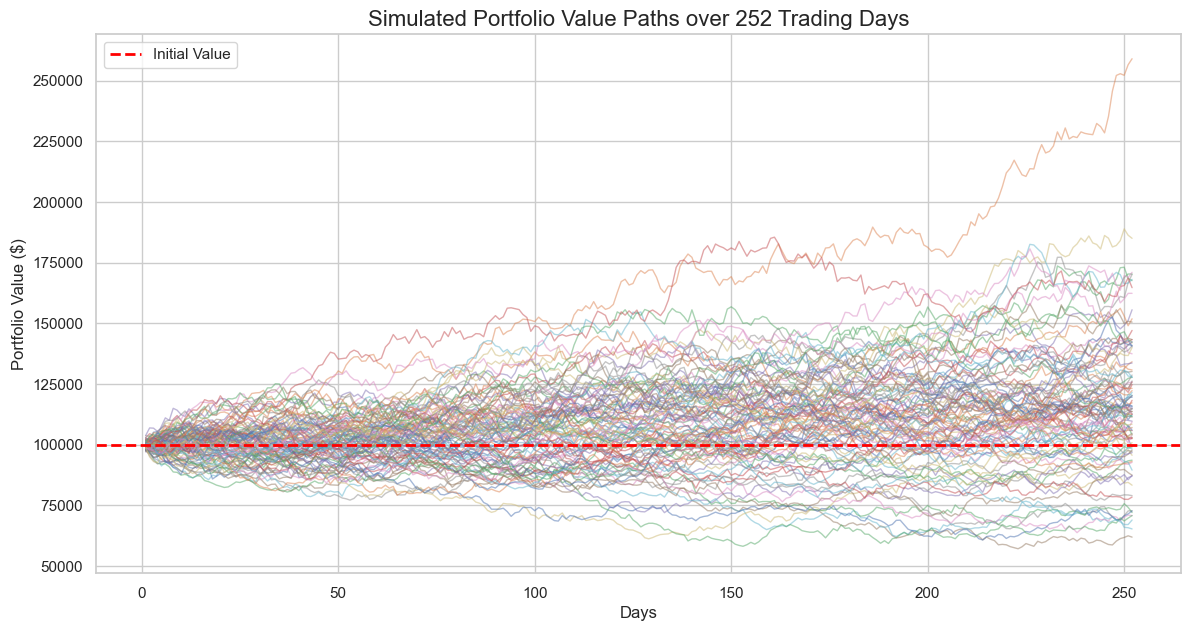

In [17]:
plt.figure(figsize=(14, 7))
# Plot first 100 paths
for i in range(100):
    plt.plot(np.arange(1, time_horizon + 1), portfolio_paths[:, i], lw=1, alpha=0.5)

plt.axhline(initial_portfolio_value, color='red', linestyle='--', linewidth=2, label='Initial Value')
plt.title(f'Simulated Portfolio Value Paths over {time_horizon} Trading Days', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Portfolio Value ($)', fontsize=12)
plt.legend()
plt.show()


### 4.1 Value at Risk (VaR) and Expected Shortfall (ES)
VaR answers: *'What is my worst expected loss at a given confidence level?'*
ES answers: *'If that worst expected loss happens, what is my expected average loss?'*


In [18]:
# Calculate Portfolio Returns over the time horizon
portfolio_returns = (portfolio_end_values - initial_portfolio_value) / initial_portfolio_value

confidence_levels = [0.95, 0.99]
summary_rows = []

for cl in confidence_levels:
    # VaR is the percentile of the distribution
    alpha = 1 - cl
    var_percentile = np.percentile(portfolio_returns, alpha * 100)
    var_dollar = initial_portfolio_value * var_percentile

    # ES is the average of the returns worse than VaR
    tail_returns = portfolio_returns[portfolio_returns <= var_percentile]
    es_percent = tail_returns.mean()
    es_dollar = initial_portfolio_value * es_percent

    print(f"--- For {cl*100}% Confidence Level ---")
    print(f"Value at Risk (VaR):    {var_percentile*100:6.2f}% | Expected Loss: ${-var_dollar:,.2f}")
    print(f"Expected Shortfall (ES): {es_percent*100:6.2f}% | Expected Loss: ${-es_dollar:,.2f}\n")

    summary_rows.append(
        {
            "Confidence Level": f"{int(cl*100)}%",
            "VaR (%)": var_percentile * 100,
            "VaR ($)": -var_dollar,
            "ES (%)": es_percent * 100,
            "ES ($)": -es_dollar,
            "Mean Return (%)": portfolio_returns.mean() * 100,
            "Volatility (%)": portfolio_returns.std() * 100,
        }
    )


--- For 95.0% Confidence Level ---
Value at Risk (VaR):    -22.81% | Expected Loss: $22,805.06
Expected Shortfall (ES): -29.55% | Expected Loss: $29,545.67

--- For 99.0% Confidence Level ---
Value at Risk (VaR):    -33.61% | Expected Loss: $33,612.22
Expected Shortfall (ES): -38.99% | Expected Loss: $38,990.53



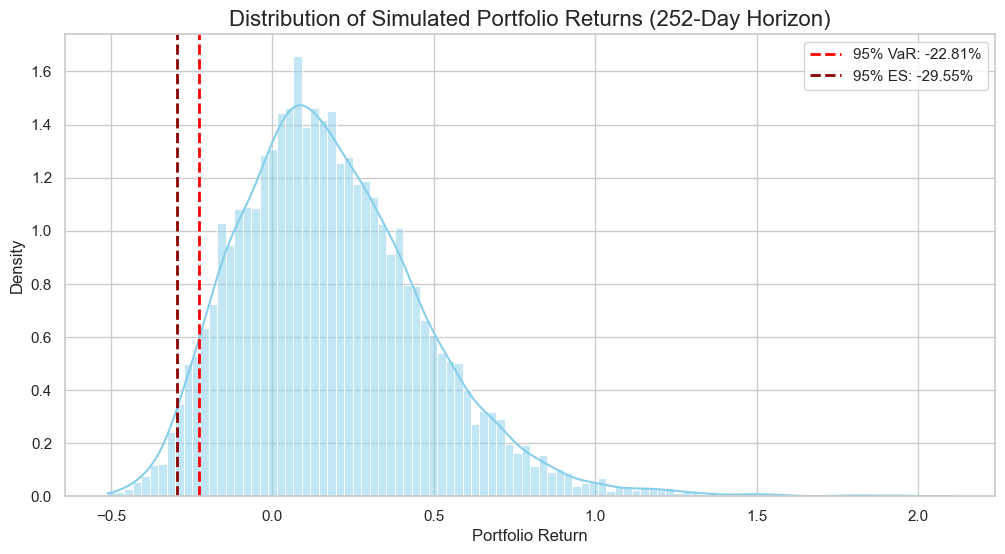

In [13]:
# Plot the distribution of portfolio returns
plt.figure(figsize=(12, 6))
sns.histplot(portfolio_returns, bins=100, kde=True, color='skyblue', stat='density')

# Highlight VaR for 95%
var_95 = np.percentile(portfolio_returns, 5)
es_95 = portfolio_returns[portfolio_returns <= var_95].mean()

plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2, label=f'95% VaR: {var_95*100:.2f}%')
plt.axvline(es_95, color='darkred', linestyle='dashed', linewidth=2, label=f'95% ES: {es_95*100:.2f}%')

plt.title(f'Distribution of Simulated Portfolio Returns ({time_horizon}-Day Horizon)', fontsize=16)
plt.xlabel('Portfolio Return', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()


In [14]:
from tabulate import tabulate
from scipy.stats import norm

def display_results(sim_results):
    portfolio_returns = sim_results['portfolio_returns']
    initial_value = sim_results['initial_portfolio_value']
    tickers = sim_results['tickers']
    weights = sim_results['weights']
    vols = sim_results['volatilities']
    cov_matrix = sim_results['cov_matrix']
    
    print("\n" + "="*70)
    print("MONTE CARLO SIMULATION RESULTS (21-Day Horizon)".center(70))
    print("="*70 + "\n")
    
    # 1. Return Distribution by Percentile
    percentiles = [1, 5, 10, 25, 50, 75, 90, 99]
    labels = {
        1: "VaR 99% threshold",
        5: "VaR 95% threshold",
        50: "Median outcome"
    }
    
    dist_data = []
    for p in percentiles:
        ret = np.percentile(portfolio_returns, p)
        pnl = initial_value * ret
        label = labels.get(p, "")
        dist_data.append([f"P{p}", f"${pnl:,.2f}", f"{ret*100:.2f}%", label])
        
    print("--- 1. Return Distribution by Percentile ---")
    print(tabulate(dist_data, headers=["Percentile", "P&L", "Return", "Note"], tablefmt="simple"))
    print("\n")
    
    # 2. Risk Metrics Summary
    var_95 = np.percentile(portfolio_returns, 5)
    var_99 = np.percentile(portfolio_returns, 1)
    cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()
    cvar_99 = portfolio_returns[portfolio_returns <= var_99].mean()
    
    metrics_data = [
        ["VaR 95%", f"${-initial_value * var_95:,.2f}", f"{-var_95*100:.2f}%"],
        ["VaR 99%", f"${-initial_value * var_99:,.2f}", f"{-var_99*100:.2f}%"],
        ["CVaR 95%", f"${-initial_value * cvar_95:,.2f}", f"{-cvar_95*100:.2f}%"],
        ["CVaR 99%", f"${-initial_value * cvar_99:,.2f}", f"{-cvar_99*100:.2f}%"],
        ["Max Simulated Loss", f"${initial_value * portfolio_returns.min():,.2f}", f"{portfolio_returns.min()*100:.2f}%"],
        ["Max Simulated Gain", f"${initial_value * portfolio_returns.max():,.2f}", f"{portfolio_returns.max()*100:.2f}%"],
        ["Mean Return", f"${initial_value * portfolio_returns.mean():,.2f}", f"{portfolio_returns.mean()*100:.2f}%"],
        ["Std Deviation", "-", f"{portfolio_returns.std()*100:.2f}%"],
    ]
    
    print("--- 2. Risk Metrics Summary ---")
    print(tabulate(metrics_data, headers=["Metric", "Amount ($)", "Percentage"], tablefmt="simple"))
    print("\n")
    
    # 3. Per-Asset VaR Contribution
    # Parametric approximation scaled to Monte Carlo VaR
    port_vol = np.sqrt(weights.T @ (cov_matrix * 21) @ weights)
    z_score = norm.ppf(0.05)
    port_var_parametric = -z_score * port_vol
    
    marginal_var = -z_score * ((cov_matrix * 21) @ weights) / port_vol
    component_var = weights * marginal_var
    component_var_pct = component_var / port_var_parametric
    
    # Scale back to simulated 95% dollar VaR amount for consistency
    mc_var_dollar = -initial_value * var_95
    scaled_component_var_dollar = component_var_pct * mc_var_dollar
    
    asset_data = []
    for i, t in enumerate(tickers):
        ann_vol = vols[i] * np.sqrt(252)
        asset_data.append([
            t, 
            f"{weights[i]*100:.1f}%", 
            f"{ann_vol*100:.1f}%", 
            f"${scaled_component_var_dollar[i]:,.2f}", 
            f"{component_var_pct[i]*100:.1f}%"
        ])
        
    print("--- 3. Per-Asset VaR Contribution (95%) ---")
    print(tabulate(asset_data, headers=["Asset", "Weight", "Ann. Vol", "VaR Contrib ($)", "VaR Contrib (%)"], tablefmt="simple"))
    print("\n")
    
    # 4. Probability of Loss Thresholds
    thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40]
    prob_data = []
    
    for t in thresholds:
        prob = np.mean(portfolio_returns < -t)
        if prob > 0:
            # Expected years for 1 event, given 252 trading days and 21-day horizon
            # P(event in 21 days) = prob
            # Events per year = (252/21) * prob
            # Years per event = 1 / events_per_year
            years = 1 / ((252 / 21) * prob)
            freq = f"1 in {years:.1f} years"
        else:
            freq = "N/A (< 1 in 100,000)"
            
        prob_data.append([f"> {t*100:.0f}%", f"{prob*100:.3f}%", freq])
        
    print("--- 4. Probability of Loss Thresholds ---")
    print(tabulate(prob_data, headers=["Loss Threshold", "Probability", "Expected Frequency"], tablefmt="simple"))

# Prepare data for the display function
sim_results = {
    'portfolio_returns': portfolio_returns,
    'initial_portfolio_value': initial_portfolio_value,
    'tickers': tickers,
    'weights': weights,
    'volatilities': volatilities,
    'cov_matrix': cov_matrix
}

display_results(sim_results)


           MONTE CARLO SIMULATION RESULTS (21-Day Horizon)            

--- 1. Return Distribution by Percentile ---
Percentile    P&L          Return    Note
------------  -----------  --------  -----------------
P1            $-33,612.20  -33.61%   VaR 99% threshold
P5            $-22,805.05  -22.81%   VaR 95% threshold
P10           $-15,973.44  -15.97%
P25           $-2,053.69   -2.05%
P50           $15,216.42   15.22%    Median outcome
P75           $35,650.32   35.65%
P90           $56,246.59   56.25%
P99           $103,252.25  103.25%


--- 2. Risk Metrics Summary ---
Metric              Amount ($)    Percentage
------------------  ------------  ------------
VaR 95%             $22,805.05    22.81%
VaR 99%             $33,612.20    33.61%
CVaR 95%            $29,545.66    29.55%
CVaR 99%            $38,990.52    38.99%
Max Simulated Loss  $-51,062.37   -51.06%
Max Simulated Gain  $210,844.20   210.84%
Mean Return         $18,503.92    18.50%
Std Deviation       -             29

## 5. Conclusion
This simulation demonstrates how the inter-correlation and historical volatility of a tech-heavy portfolio affects tail risk. The VaR tells us the minimum threshold of our worst 5% of outcomes, while the ES gives a more accurate measure of the extent of tail losses in those 5% of scenarios. Continuing this project, one could expand this by examining different portfolio weights or incorporating options for hedging.
